# Fashion MNIST Transfer Learning

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Load Data Samples

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, y_train = x_train[:5000], y_train[:5000]
x_test, y_test = x_test[:1000], y_test[:1000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Preprocess

In [3]:
# Preprocess to flat vectors
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

# Train a simple classifier

In [4]:
# Train a simple classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

# Accuracy


In [5]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")

Test Accuracy: 0.82


# Classification report

In [6]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       107
           1       0.95      0.96      0.96       105
           2       0.71      0.69      0.70       111
           3       0.79      0.76      0.78        93
           4       0.77      0.71      0.74       115
           5       0.93      0.93      0.93        87
           6       0.51      0.63      0.56        97
           7       0.95      0.93      0.94        95
           8       0.96      0.92      0.94        95
           9       0.94      0.96      0.95        95

    accuracy                           0.82      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.82      0.82      1000



# Confusion Matrix

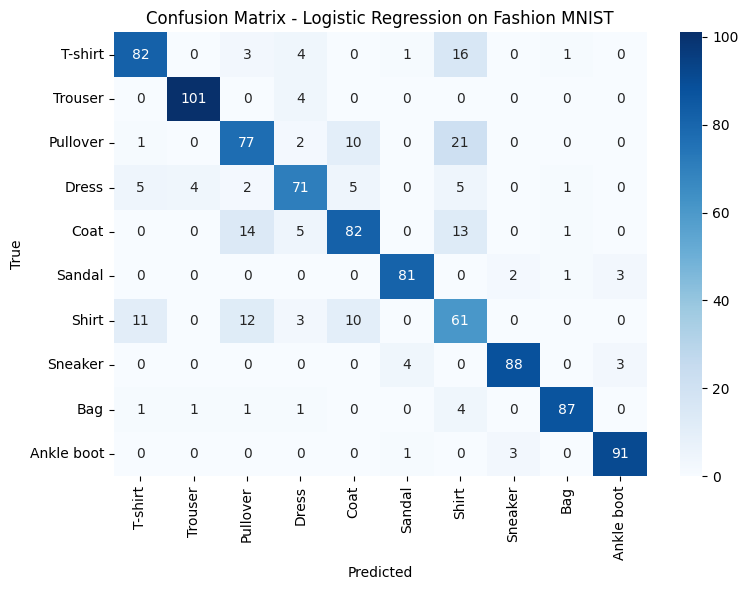

In [7]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Logistic Regression on Fashion MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Visualization of predictions

<ipython-input-8-3a641b3cab47>:16: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-8-3a641b3cab47>:16: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


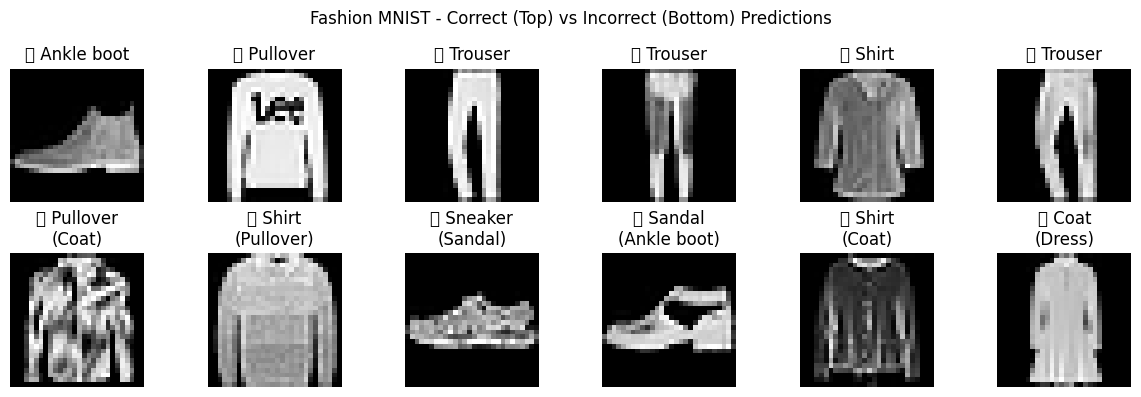

In [8]:

correct = np.where(y_pred == y_test)[0][:6]
incorrect = np.where(y_pred != y_test)[0][:6]

plt.figure(figsize=(12, 4))
for idx, i in enumerate(correct):
    plt.subplot(2, 6, idx+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f" {class_names[y_pred[i]]}")
    plt.axis('off')
for idx, i in enumerate(incorrect):
    plt.subplot(2, 6, idx+7)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f" {class_names[y_pred[i]]}\n({class_names[y_test[i]]})")
    plt.axis('off')
plt.suptitle("Fashion MNIST - Correct (Top) vs Incorrect (Bottom) Predictions")
plt.tight_layout()
plt.show()

# Accuracy bar plot

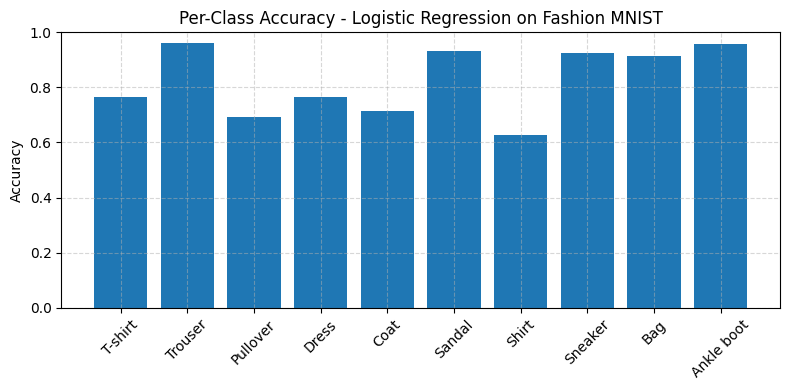

In [9]:
# Per-class accuracy bar plot
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
plt.bar(class_names, per_class_accuracy)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Logistic Regression on Fashion MNIST")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()